# Introduction to Control Systems with Python

Welcome to your journey learning control systems! This notebook will guide you through the fundamentals of control systems using Python.

## What You'll Learn
- Setting up Python environment for control systems
- Basic control theory concepts
- Transfer functions and system representations
- Time and frequency domain analysis
- Controller design basics

## Prerequisites
- Basic Python knowledge
- Elementary calculus and linear algebra
- Basic understanding of differential equations (helpful but not required)

Let's start!

## 1. Install Python and Required Libraries

First, make sure you have Python installed. Then install the essential libraries for control systems analysis.

In [1]:
# Install required packages (run this in terminal or uncomment and run here)
# !pip install numpy scipy matplotlib control sympy jupyter pandas

# Check if packages are installed
try:
    import numpy as np
    import scipy
    import matplotlib.pyplot as plt
    import control
    print("✓ All packages are installed!")
    print(f"NumPy version: {np.__version__}")
    print(f"SciPy version: {scipy.__version__}")
    print(f"Control version: {control.__version__}")
except ImportError as e:
    print(f"✗ Missing package: {e}")
    print("Please install missing packages using: pip install numpy scipy matplotlib control")

✓ All packages are installed!
NumPy version: 2.3.5
SciPy version: 1.16.3
Control version: 0.10.2


## 2. Import Control System Libraries

Let's import all the necessary libraries for control system analysis.

In [2]:
# Essential libraries for control systems
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import control as ct
from scipy import linalg
import sympy as sp

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8')

print("Libraries imported successfully!")
print("Ready for control systems analysis!")

Libraries imported successfully!
Ready for control systems analysis!


## 3. Define Transfer Functions

Transfer functions are mathematical representations of linear time-invariant systems. They describe the relationship between input and output in the Laplace domain.

In [3]:
# Method 1: Define transfer function using numerator and denominator coefficients
# Example: G(s) = 5 / (s^2 + 3s + 2)
num = [5]           # Numerator coefficients [5]
den = [1, 3, 2]     # Denominator coefficients [s^2, s^1, s^0]

G1 = ct.TransferFunction(num, den)
print("Transfer Function G1:")
print(G1)

# Method 2: Using symbolic representation
s = ct.TransferFunction.s  # Laplace variable s

# Example: G(s) = 10 / (s + 5)
G2 = 10 / (s + 5)
print("\nTransfer Function G2:")
print(G2)

# Method 3: More complex example
# G(s) = (2s + 3) / (s^3 + 4s^2 + 5s + 6)
G3 = (2*s + 3) / (s**3 + 4*s**2 + 5*s + 6)
print("\nTransfer Function G3:")
print(G3)

Transfer Function G1:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        5
  -------------
  s^2 + 3 s + 2

Transfer Function G2:
<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   10
  -----
  s + 5

Transfer Function G3:
<TransferFunction>: sys[24]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         2 s + 3
  ---------------------
  s^3 + 4 s^2 + 5 s + 6


## 4. Plot Step and Impulse Responses

Step and impulse responses are fundamental ways to analyze system behavior in the time domain.

System Transfer Function:
<TransferFunction>: sys[34]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        4
  -------------
  s^2 + 2 s + 4


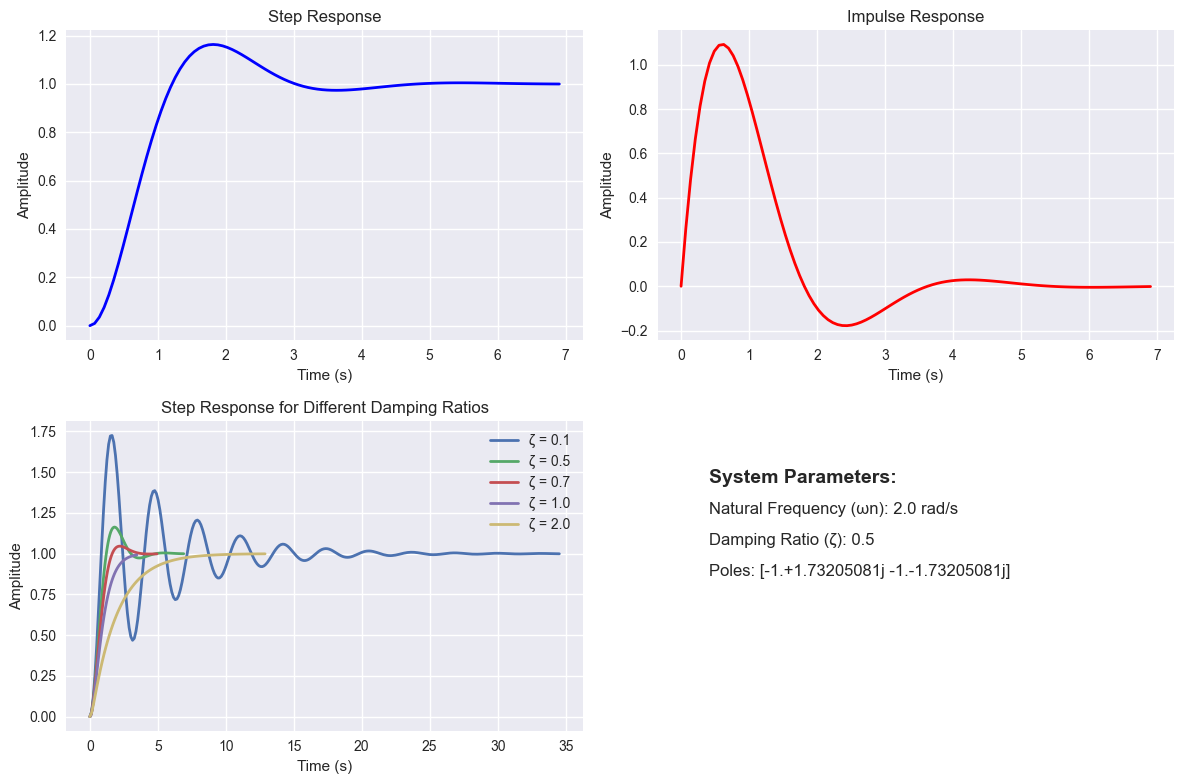

In [4]:
# Let's use a simple second-order system for analysis
# G(s) = 1 / (s^2 + 2*zeta*wn*s + wn^2)
# where zeta = damping ratio, wn = natural frequency

wn = 2.0    # Natural frequency (rad/s)
zeta = 0.5  # Damping ratio

# Create the transfer function
G = wn**2 / (s**2 + 2*zeta*wn*s + wn**2)
print("System Transfer Function:")
print(G)

# Plot step response
plt.figure(figsize=(12, 8))

# Step response
plt.subplot(2, 2, 1)
t_step, y_step = ct.step_response(G)
plt.plot(t_step, y_step, 'b-', linewidth=2)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Impulse response
plt.subplot(2, 2, 2)
t_impulse, y_impulse = ct.impulse_response(G)
plt.plot(t_impulse, y_impulse, 'r-', linewidth=2)
plt.title('Impulse Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Compare different damping ratios
plt.subplot(2, 2, 3)
for zeta_val in [0.1, 0.5, 0.7, 1.0, 2.0]:
    G_temp = wn**2 / (s**2 + 2*zeta_val*wn*s + wn**2)
    t, y = ct.step_response(G_temp)
    plt.plot(t, y, label=f'ζ = {zeta_val}', linewidth=2)

plt.title('Step Response for Different Damping Ratios')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# System information
plt.subplot(2, 2, 4)
plt.text(0.1, 0.8, f'System Parameters:', fontsize=14, fontweight='bold', transform=plt.gca().transAxes)
plt.text(0.1, 0.7, f'Natural Frequency (ωn): {wn} rad/s', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.6, f'Damping Ratio (ζ): {zeta}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.5, f'Poles: {np.roots([1, 2*zeta*wn, wn**2])}', fontsize=12, transform=plt.gca().transAxes)
plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Analyze System Stability

Stability is crucial in control systems. A system is stable if its output remains bounded for any bounded input.

In [ ]:
# Check stability by analyzing poles
def analyze_stability(tf_system, name):
    """Analyze stability of a transfer function system."""
    print(f"\n=== Stability Analysis for {name} ===")
    
    # Get poles
    poles = ct.pole(tf_system)
    print(f"Poles: {poles}")
    
    # Check stability
    is_stable = all(np.real(pole) < 0 for pole in poles)
    print(f"System is {'STABLE' if is_stable else 'UNSTABLE'}")
    
    # Additional stability metrics
    if is_stable:
        # Calculate settling time (2% criterion)
        dominant_pole = max(poles, key=lambda x: np.real(x))
        if np.imag(dominant_pole) == 0:
            settling_time = 4 / abs(np.real(dominant_pole))
        else:
            settling_time = 4 / abs(np.real(dominant_pole))
        print(f"Approximate settling time: {settling_time:.2f} seconds")
    
    return is_stable, poles

# Test different systems
systems = [
    (ct.TransferFunction([1], [1, 2, 1]), "Stable System"),
    (ct.TransferFunction([1], [1, -1, 1]), "Unstable System"),
    (ct.TransferFunction([1], [1, 0, 1]), "Marginally Stable System"),
    (G, "Our Second-Order System")
]

for system, name in systems:
    analyze_stability(system, name)

## 6. Design Basic Controllers (PID)

PID (Proportional-Integral-Derivative) controllers are the most common controllers in industry. Let's design and tune a simple PID controller.

In [ ]:
# Define a plant to control
# Plant: G(s) = 1 / (s^2 + s + 1)
plant = ct.TransferFunction([1], [1, 1, 1])
print("Plant Transfer Function:")
print(plant)

# Design PID controller: C(s) = Kp + Ki/s + Kd*s
# PID in transfer function form: C(s) = (Kd*s^2 + Kp*s + Ki) / s

# PID parameters (you can tune these!)
Kp = 2.0   # Proportional gain
Ki = 1.0   # Integral gain  
Kd = 0.5   # Derivative gain

# Create PID controller transfer function
# C(s) = (Kd*s^2 + Kp*s + Ki) / s
pid_controller = ct.TransferFunction([Kd, Kp, Ki], [1, 0])
print(f"\nPID Controller (Kp={Kp}, Ki={Ki}, Kd={Kd}):")
print(pid_controller)

# Alternative method using built-in PID function
pid_controller_alt = ct.pid(Kp, Ki, Kd)
print(f"\nAlternative PID Controller:")
print(pid_controller_alt)

# Compare step responses with different controller types
plt.figure(figsize=(15, 10))

# No controller (open-loop)
plt.subplot(2, 3, 1)
t, y = ct.step_response(plant)
plt.plot(t, y, 'b-', linewidth=2)
plt.title('Open-Loop (No Controller)')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid(True)

# P controller only
Kp_only = ct.TransferFunction([Kp], [1])
closed_loop_P = ct.feedback(Kp_only * plant, 1)
plt.subplot(2, 3, 2)
t, y = ct.step_response(closed_loop_P)
plt.plot(t, y, 'r-', linewidth=2)
plt.title(f'P Controller (Kp={Kp})')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid(True)

# PI controller
Ki_tf = ct.TransferFunction([Ki], [1, 0])
PI_controller = Kp_only + Ki_tf
closed_loop_PI = ct.feedback(PI_controller * plant, 1)
plt.subplot(2, 3, 3)
t, y = ct.step_response(closed_loop_PI)
plt.plot(t, y, 'g-', linewidth=2)
plt.title(f'PI Controller (Kp={Kp}, Ki={Ki})')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid(True)

# PD controller  
Kd_tf = ct.TransferFunction([Kd, 0], [1])
PD_controller = Kp_only + Kd_tf
closed_loop_PD = ct.feedback(PD_controller * plant, 1)
plt.subplot(2, 3, 4)
t, y = ct.step_response(closed_loop_PD)
plt.plot(t, y, 'm-', linewidth=2)
plt.title(f'PD Controller (Kp={Kp}, Kd={Kd})')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid(True)

# Full PID controller
closed_loop_PID = ct.feedback(pid_controller_alt * plant, 1)
plt.subplot(2, 3, 5)
t, y = ct.step_response(closed_loop_PID)
plt.plot(t, y, 'k-', linewidth=2)
plt.title(f'PID Controller (Kp={Kp}, Ki={Ki}, Kd={Kd})')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid(True)

# Comparison of all controllers
plt.subplot(2, 3, 6)
controllers = [
    (plant, 'Open-Loop', 'blue'),
    (closed_loop_P, 'P Controller', 'red'),
    (closed_loop_PI, 'PI Controller', 'green'),
    (closed_loop_PD, 'PD Controller', 'magenta'),
    (closed_loop_PID, 'PID Controller', 'black')
]

for sys, name, color in controllers:
    t, y = ct.step_response(sys)
    plt.plot(t, y, color=color, label=name, linewidth=2)

plt.title('Controller Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print system information
print(f"\nClosed-loop PID system poles: {ct.pole(closed_loop_PID)}")
is_stable, _ = analyze_stability(closed_loop_PID, "PID Closed-Loop")

## 7. Frequency Domain Analysis - Bode Plots

Bode plots show how a system responds to different frequencies, which is crucial for understanding system behavior and designing controllers.

In [ ]:
# Create Bode plots for our systems
plt.figure(figsize=(15, 10))

# System for analysis
systems_to_plot = [
    (plant, 'Plant G(s)', 'blue'),
    (pid_controller_alt, 'PID Controller C(s)', 'red'),
    (pid_controller_alt * plant, 'Open-Loop L(s) = C(s)G(s)', 'green'),
    (closed_loop_PID, 'Closed-Loop T(s)', 'black')
]

for i, (system, name, color) in enumerate(systems_to_plot):
    # Create subplot for magnitude
    plt.subplot(2, 2, 1)
    if i == 0:
        plt.title('Magnitude Response')
        plt.ylabel('Magnitude (dB)')
    
    # Get frequency response
    omega = np.logspace(-2, 2, 1000)  # Frequency range from 0.01 to 100 rad/s
    mag, phase, omega = ct.bode_plot(system, omega, dB=True, Hz=False, 
                                   color=color, label=name, plot=True)
    
    # Create subplot for phase
    plt.subplot(2, 2, 3)
    if i == 0:
        plt.title('Phase Response')
        plt.xlabel('Frequency (rad/s)')
        plt.ylabel('Phase (degrees)')

# Add legends
plt.subplot(2, 2, 1)
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.legend()
plt.grid(True)

# Nyquist plot
plt.subplot(2, 2, 2)
ct.nyquist_plot(pid_controller_alt * plant, color='blue', linewidth=2)
plt.title('Nyquist Plot (Open-Loop)')
plt.grid(True)

# Nichols chart
plt.subplot(2, 2, 4)
ct.nichols_plot(pid_controller_alt * plant, color='red', linewidth=2)
plt.title('Nichols Chart (Open-Loop)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate stability margins
gm, pm, wg, wp = ct.margin(pid_controller_alt * plant)
print(f"\nStability Margins for Open-Loop System:")
print(f"Gain Margin: {gm:.2f} ({20*np.log10(gm):.2f} dB)")
print(f"Phase Margin: {pm:.2f} degrees")
print(f"Gain Crossover Frequency: {wg:.2f} rad/s")
print(f"Phase Crossover Frequency: {wp:.2f} rad/s")

## 8. Next Steps in Your Control Systems Journey

Congratulations! You've completed the basic introduction to control systems with Python. Here's what to explore next:

### 🎯 What You've Learned
- ✅ Set up Python environment for control systems
- ✅ Created and analyzed transfer functions
- ✅ Plotted time domain responses (step, impulse)
- ✅ Analyzed system stability
- ✅ Designed basic PID controllers
- ✅ Explored frequency domain analysis

### 📚 Next Topics to Study
1. **Root Locus Analysis** - How system behavior changes with gain
2. **Advanced Controller Design** - Lead, lag, lead-lag compensators
3. **State-Space Methods** - Modern control theory
4. **Digital Control Systems** - Discrete-time systems
5. **Robust Control** - Handling uncertainties
6. **Optimal Control** - LQR, MPC

### 🛠️ Practice Exercises
Try these exercises to reinforce your learning:

1. Design a PID controller for a different plant
2. Compare different damping ratios and their effects
3. Analyze stability margins for various systems
4. Create Bode plots for higher-order systems

### 📖 Resources for Further Learning
- **Documentation**: [Python Control Systems Library](https://python-control.readthedocs.io/)
- **Books**: "Control Systems Engineering" by Nise
- **Online**: MIT OpenCourseWare Control Systems courses

Keep practicing and experimenting with different systems!